In [1]:
%pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.7 MB/s eta 0:00:00


In [3]:
import zipfile, os, glob

with zipfile.ZipFile("Chess Pieces.yolov8.zip", "r") as z:
    z.extractall("chess_dataset")
print("Extracted!\n")

# Show the folder structure
for root, dirs, files in os.walk("chess_dataset"):
    level = root.count(os.sep)
    print("  " * level + os.path.basename(root) + "/")
    for f in files:
        if f.endswith((".yaml", ".txt")):
            print("  " * (level + 1) + f)

# Print the data.yaml
yamls = glob.glob("chess_dataset/**/data.yaml", recursive=True)
print("\n--- yamls found:", yamls, "---\n")
if yamls:
    with open(yamls[0]) as f:
        print(f.read())

Extracted!

chess_dataset/
  data.yaml
  README.roboflow.txt
  README.dataset.txt
  valid/
    labels/
      18742c87a03866e042c5659ba04d1180_jpg.rf.TBXh3qKyIdhImdQMaff3.txt
      55be99616328f83dcbfe8c18e1387c0e_jpg.rf.tW2cUjAxqK3f0B3LHmpo.txt
      05ad7223827a29a8283f6c4b2490f52f_jpg.rf.lmLXu9wprluLhKitOfMg.txt
      3aafc2d38807dddd1b43a54cb70f500d_jpg.rf.JZpIcdxFYKEu9aRFLVcP.txt
      3e0c67f38992fe16dfc163f7f5336263_jpg.rf.nIKt2ozZNFTyMtXxLsiB.txt
      bb0de9761d16eee258ae09d8de32002c_jpg.rf.VxOMe4yUzytYNuIgsmiy.txt
      8ec14357f5f18fb98db86e0283623150_jpg.rf.wDL7AV4UZY58k1Rlms38.txt
      578029c06939a788cd5606ad17b49fb9_jpg.rf.Rd7UDRvMuXt9Nw59I2JC.txt
      33b66ede234715fb46db40b33c4e26c1_jpg.rf.JRnCRxmmaXY2yXabDlOM.txt
      d114edc5cb4cae0ceb2f152afd15f57d_jpg.rf.8qC9gYFnctZXIZVaGbk9.txt
      ca6484c259f286c5bdf1afefc868b753_jpg.rf.vWpKJxaoqM9xinaRYZwj.txt
      302e7c10664be32b4fc000452149027c_jpg.rf.fEbk9ThuMxv5kx2aebFJ.txt
      97ed198b00b5491747d3b425df8e7096_jpg.rf

In [4]:
import yaml, os

yaml_path = "chess_dataset/data.yaml"
base = os.path.abspath("chess_dataset")

with open(yaml_path) as f:
    data = yaml.safe_load(f)

data["train"] = os.path.join(base, "train/images")
data["val"]   = os.path.join(base, "valid/images")
data["test"]  = os.path.join(base, "test/images")

with open(yaml_path, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("Fixed paths:")
print("train:", data["train"])
print("val:  ", data["val"])
print("nc:   ", data["nc"])
print("names:", data["names"])

Fixed paths:
train: /content/chess_dataset/train/images
val:   /content/chess_dataset/valid/images
nc:    13
names: ['bishop', 'black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook', 'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook']


In [5]:
for split in ["train", "valid", "test"]:
    n = len(os.listdir(f"chess_dataset/{split}/images"))
    print(f"{split}: {n} images")

train: 202 images
valid: 58 images
test: 29 images


In [7]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="chess_dataset/data.yaml",
    epochs=60,
    imgsz=640,
    batch=16,
    patience=15,
    freeze=10,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    project="chess_runs",
    name="chess_yolo11n",
    plots=True,
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ Download failure, retrying 1/3 https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo11n.pt... ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=chess_dataset/data.yaml, degrees=10, deterministic=True, dev

Training run dir: /content/runs/detect/chess_runs/chess_yolo11n
results.png (training curves over epochs)


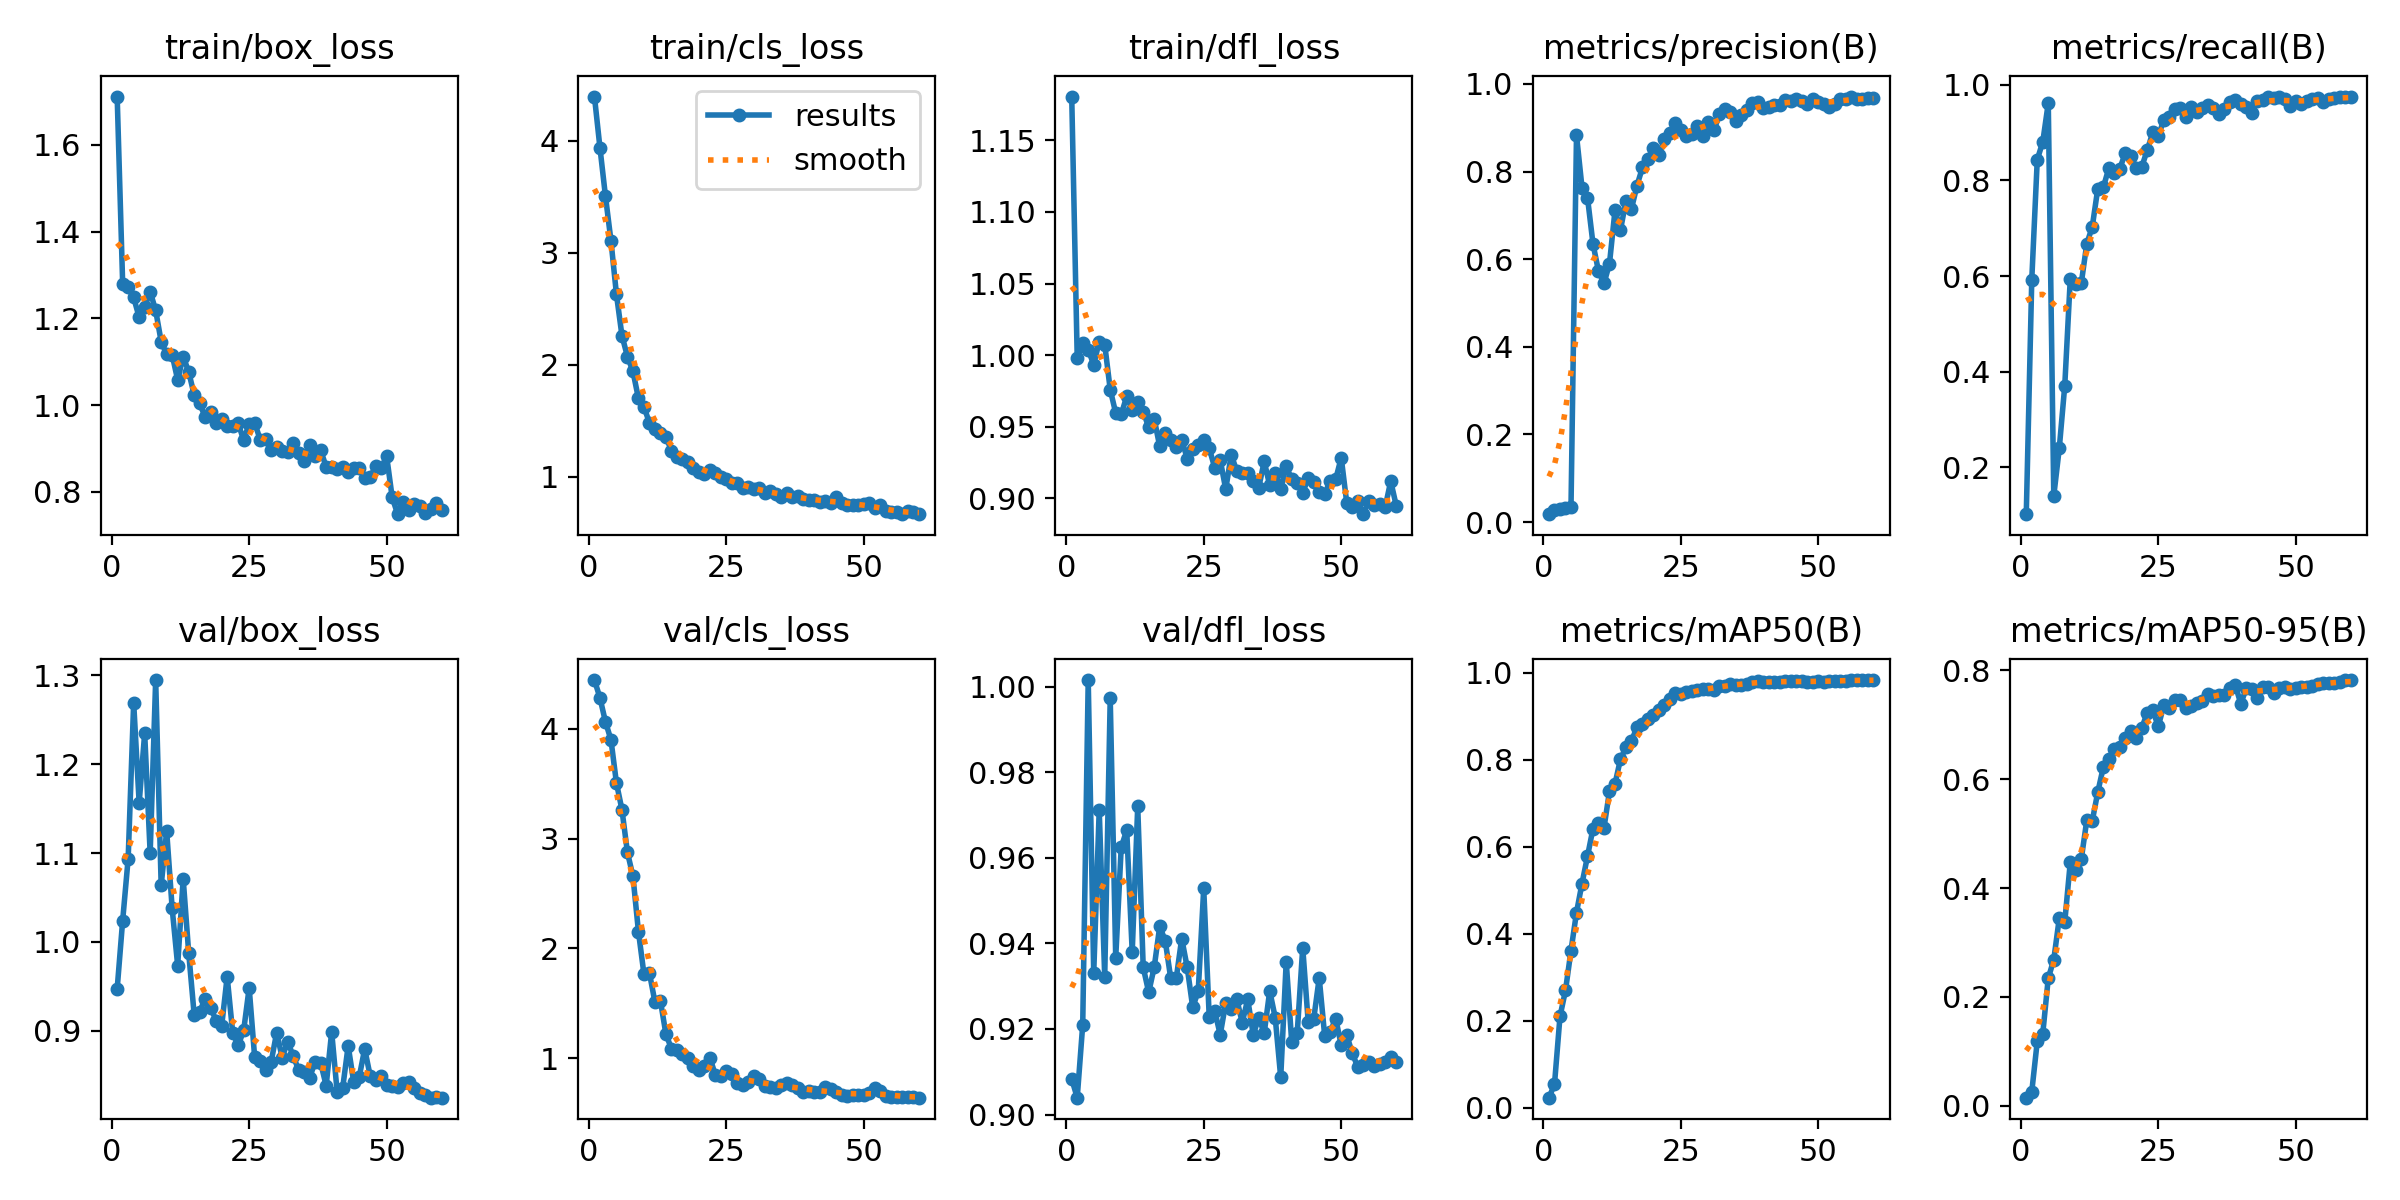

In [22]:
from IPython.display import Image as IPImage, display
import os, glob

# Training plots
run_dirs = glob.glob("/content/runs/detect/chess_runs/chess_yolo11n*")
train_dir = max(run_dirs, key=os.path.getmtime)
print("Training run dir:", train_dir)

p = os.path.join(train_dir, "results.png")
if os.path.exists(p):
    print("results.png (training curves over epochs)")
    display(IPImage(p))
else:
    print("results.png not found in", train_dir)

In [23]:
from ultralytics import YOLO
import os, glob

# Find the trained weights
run_dirs = glob.glob("/content/runs/detect/chess_runs/chess_yolo11n*")
train_dir = max(run_dirs, key=os.path.getmtime)
weights = os.path.join(train_dir, "weights", "best.pt")
print("Using weights:", weights)

model = YOLO(weights)

# Evaluate on the TEST split
metrics = model.val(
    data="chess_dataset/data.yaml",
    split="test",
    conf=0.25,
    iou=0.6,
    plots=True,
)

print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

Using weights: /content/runs/detect/chess_runs/chess_yolo11n/weights/best.pt
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,584,687 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3860.7±835.2 MB/s, size: 395.5 KB)
val: Scanning /content/chess_dataset/test/labels.cache... 29 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 29/29 9.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4it/s 1.4s
                   all         29        376      0.961      0.986      0.979      0.797
          black-bishop         12         21      0.938          1      0.986      0.828
            black-king         17         17      0.951      0.941      0.992      0.791
          black-knight         15         25      0.975          1      0.995      0.795
            black-pawn         16         86      0.985  

Eval plots in: /content/runs/detect/val-2
confusion_matrix.png


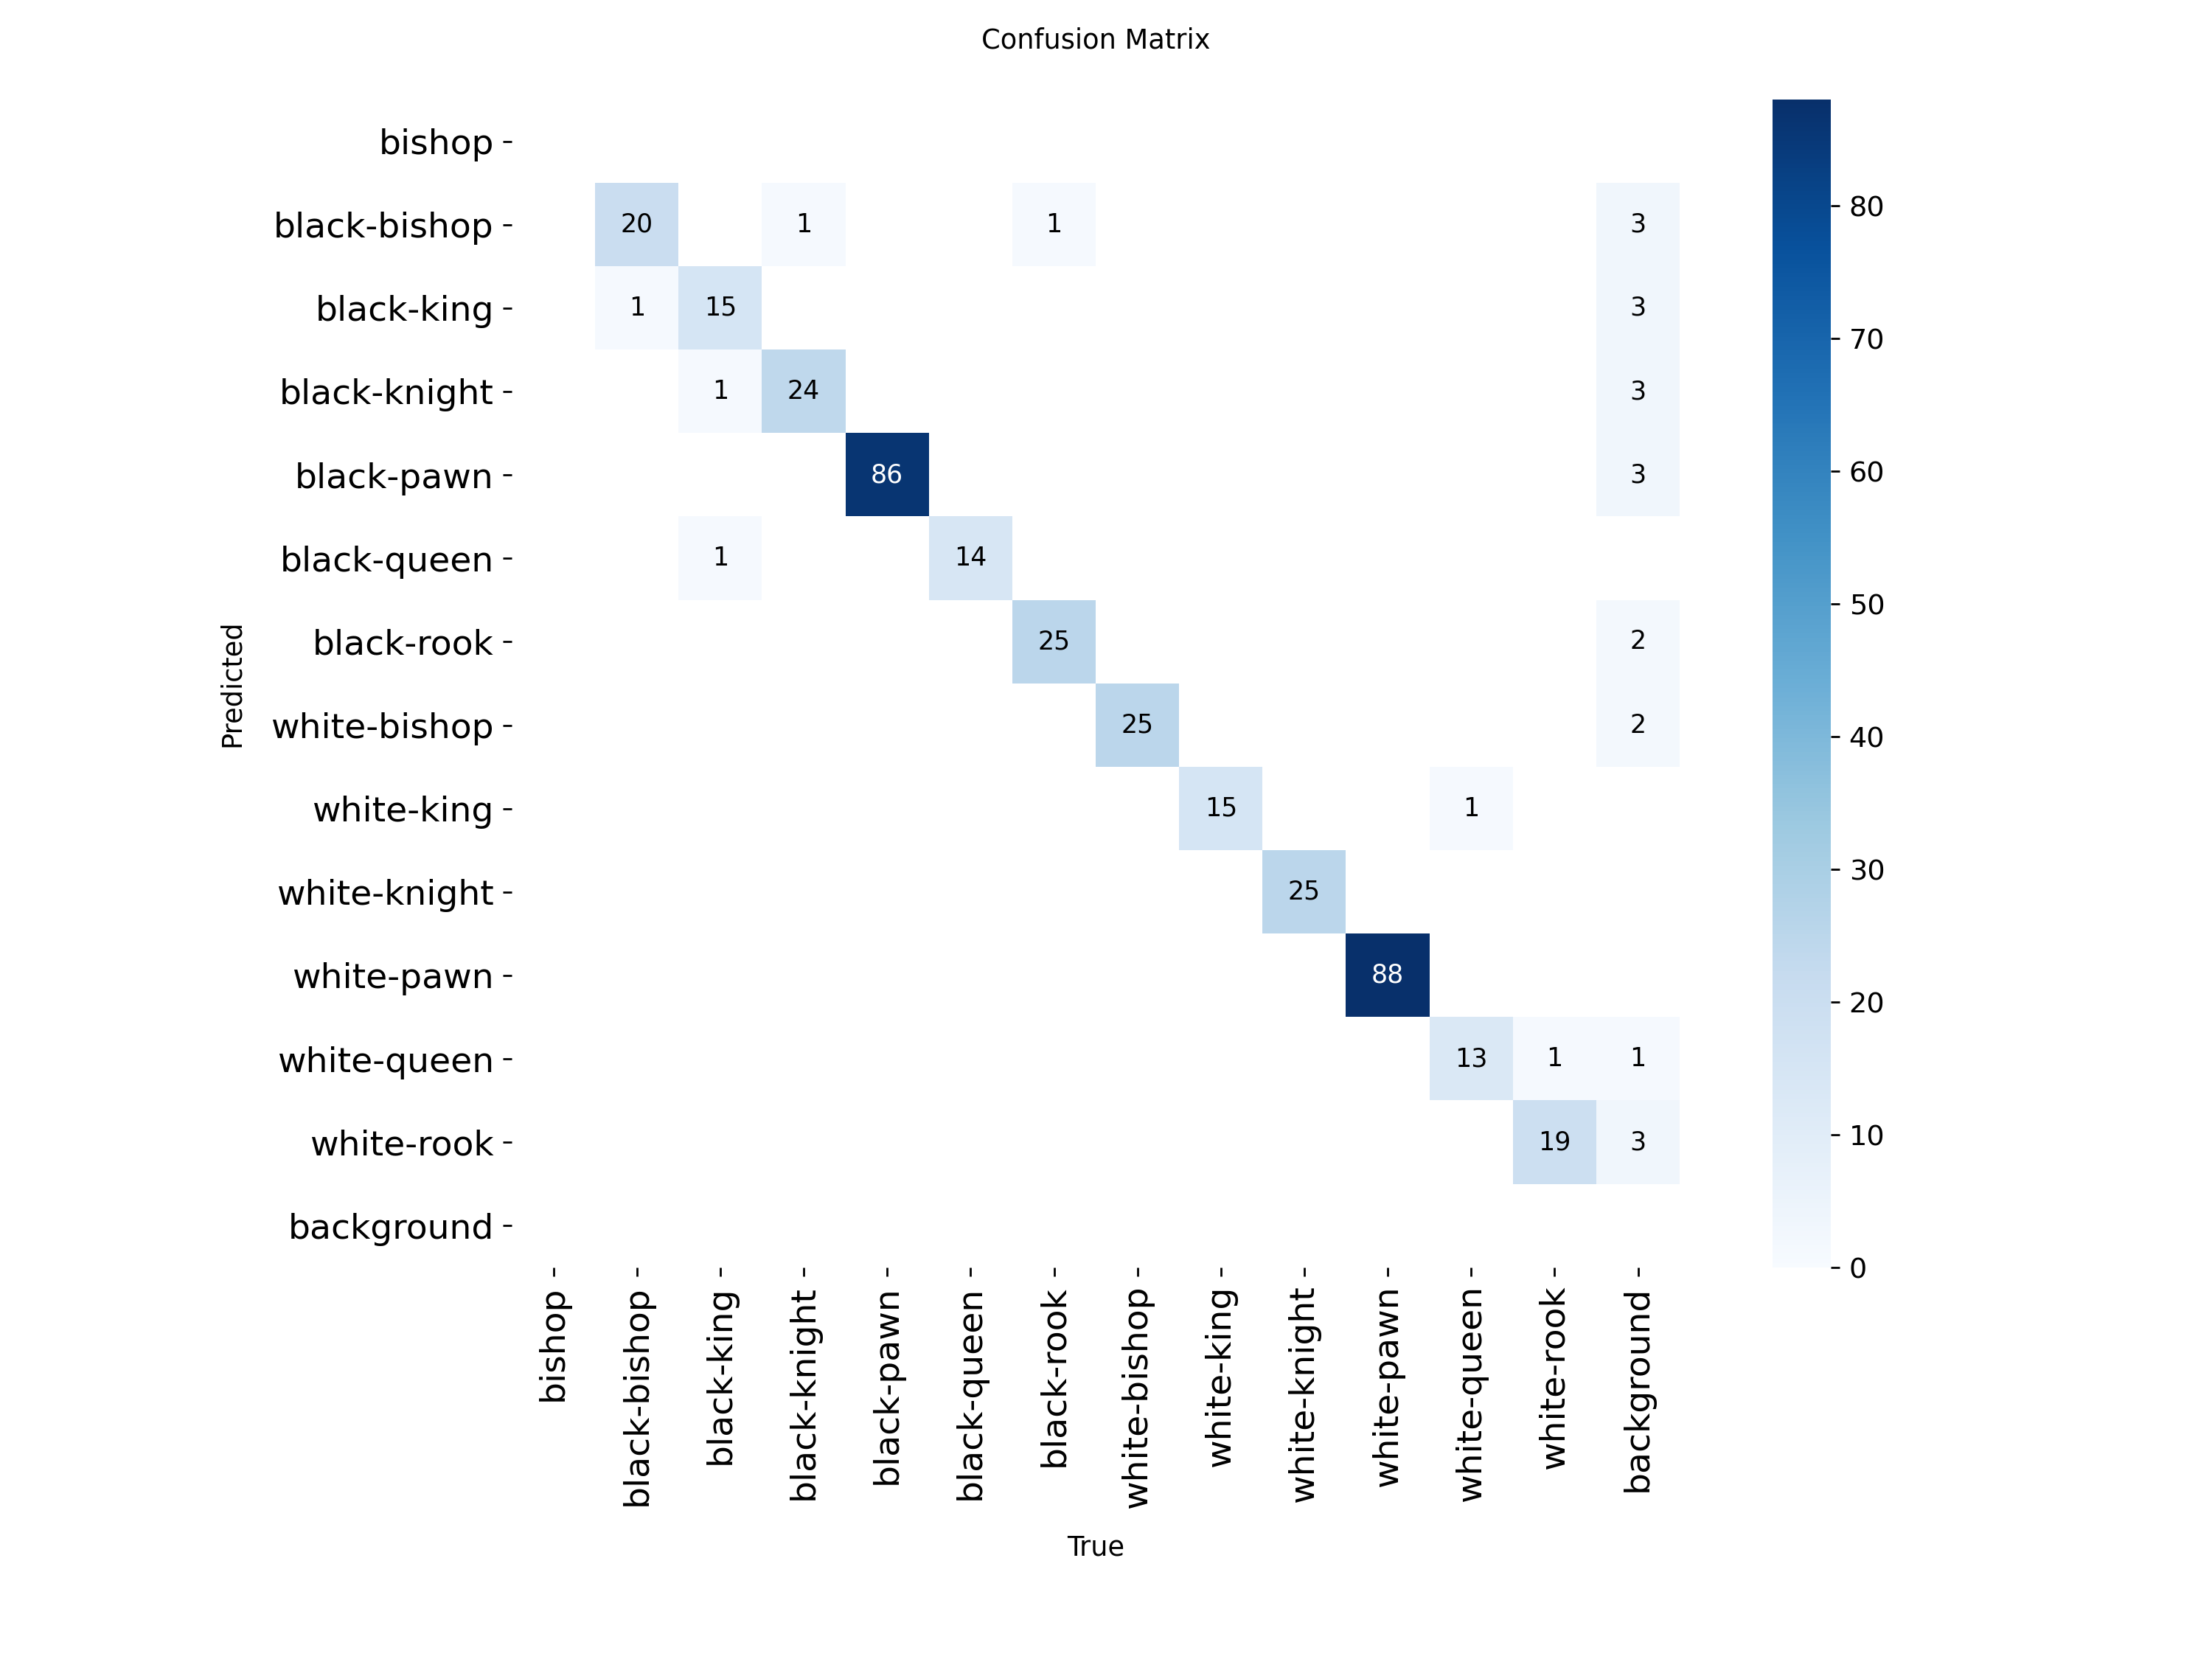

BoxPR_curve.png


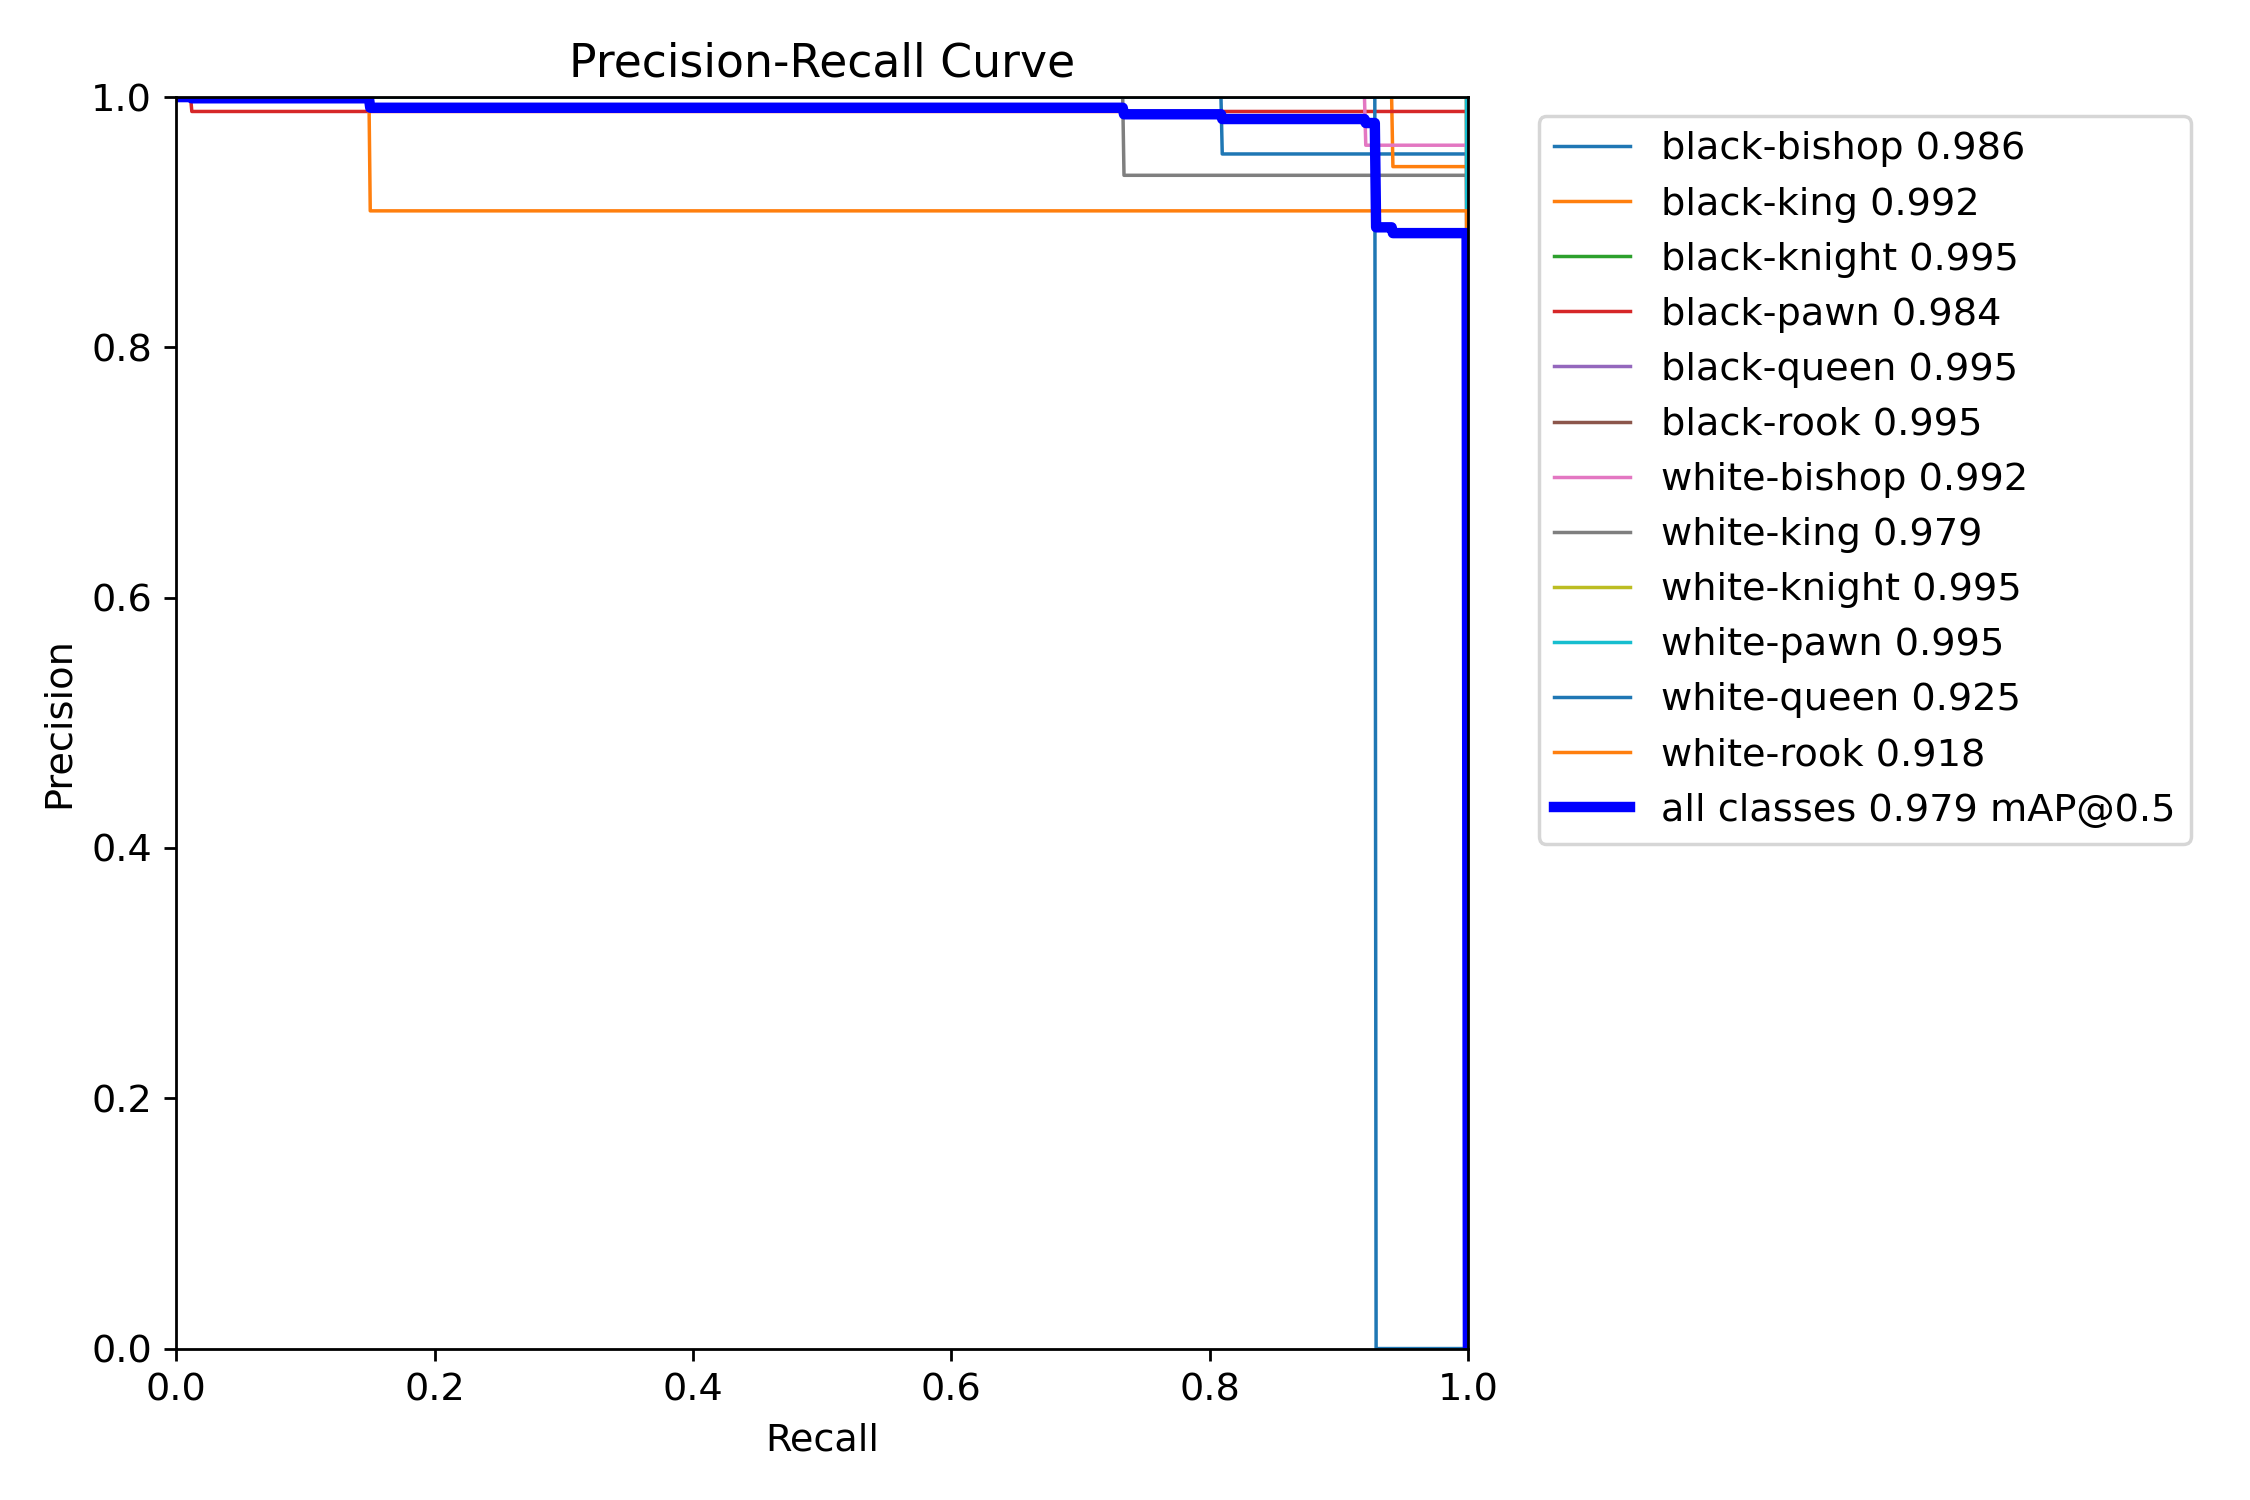

In [24]:
from IPython.display import Image as IPImage, display
import os

eval_dir = str(metrics.save_dir)
print("Eval plots in:", eval_dir)

for f in ["confusion_matrix.png", "BoxPR_curve.png"]:
    path = os.path.join(eval_dir, f)
    if os.path.exists(path):
        print(f)
        display(IPImage(path))
    else:
        print(f, "not found")


0: 448x640 1 white-knight, 3.9ms
1: 448x640 1 white-pawn, 3.9ms
2: 448x640 1 black-bishop, 1 black-king, 1 black-knight, 3 black-pawns, 1 black-rook, 1 white-bishop, 1 white-king, 1 white-knight, 3 white-pawns, 1 white-queen, 1 white-rook, 3.9ms
3: 448x640 1 black-king, 1 black-pawn, 1 black-queen, 1 black-rook, 1 white-king, 2 white-pawns, 3.9ms
4: 448x640 1 white-bishop, 3.9ms
5: 448x640 1 black-rook, 3.9ms
Speed: 2.3ms preprocess, 3.9ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


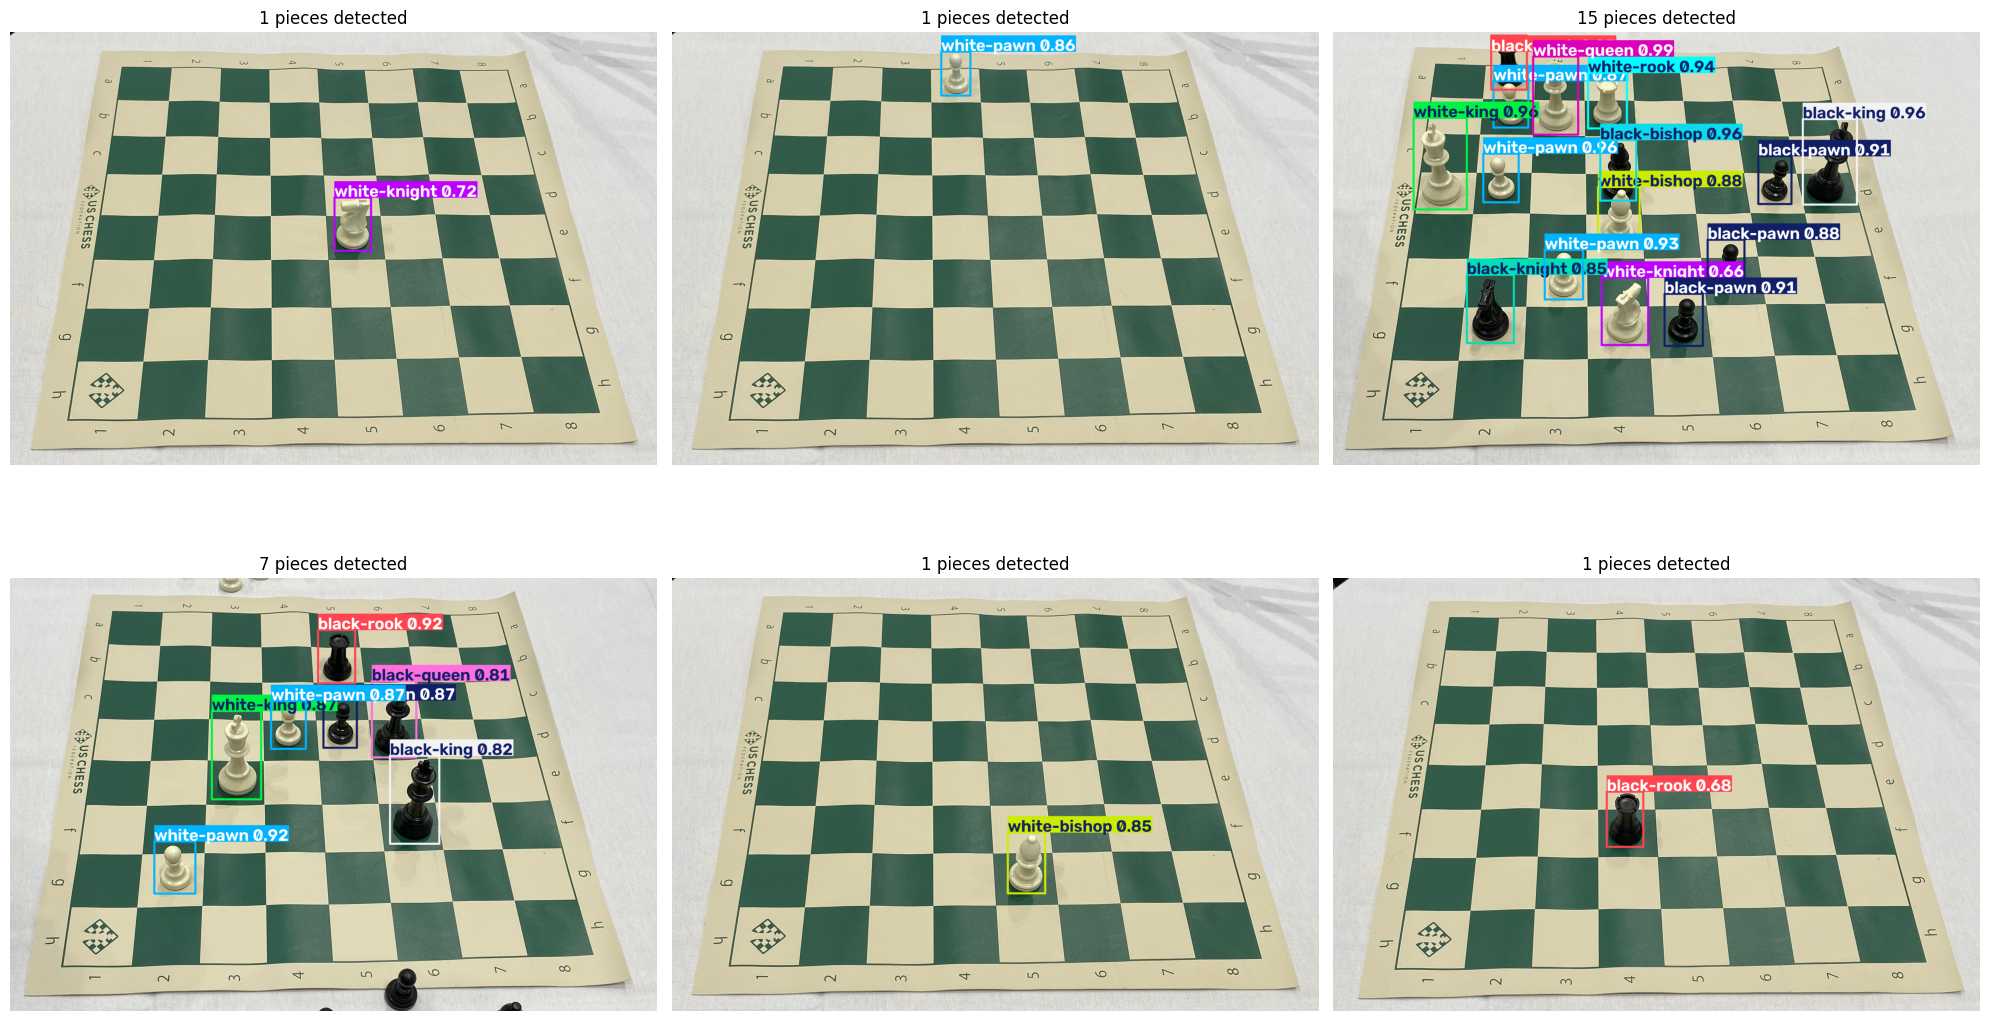

In [18]:
import glob, os, matplotlib.pyplot as plt

os.makedirs("docs", exist_ok=True)

test_imgs = glob.glob("chess_dataset/test/images/*.jpg")[:6]   # first 6 test images

results = model.predict(test_imgs, conf=0.25, save=True)

# display images
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for ax, r in zip(axes.flat, results):
    ax.imshow(r.plot()[:, :, ::-1])   # annotated prediction
    ax.axis("off")
    ax.set_title(f"{len(r.boxes)} pieces detected")
plt.tight_layout()
plt.savefig("docs/d3_test_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/chess_runs/chess_yolo11n/weights/best.pt")

# Export to ONNX
onnx_path = model.export(format="onnx")
print("Exported to:", onnx_path)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,584,687 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from '/content/runs/detect/chess_runs/chess_yolo11n/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 17, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 295ms
Prepared 4 packages in 1.84s
Installed 4 packages in 264ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.28.0
 + onnxslim==0.1.95

requirements: AutoUpdate success ✅ 2.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20